# Prévision de la consommation du lendemain

Objectif : peut-on prévoir la consommation moyenne de demain ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Préparation des données

In [2]:
eco2mix=pd.read_csv("../data/eco2mix_2023_2024.csv", sep=";")
eco2mix=eco2mix.dropna(subset=['consommation'])
eco2mix['date_heure']=pd.to_datetime(eco2mix['date_heure'])
meteo=pd.read_csv('../data/meteo_2023_2024.csv', sep=',')
meteo['date_heure'] = pd.to_datetime(meteo['date_heure']).dt.tz_localize("UTC")
eco2mix["date"] = eco2mix["date_heure"].dt.floor("D")
meteo["date"] = meteo["date_heure"].dt.floor("D")
conso_jour = eco2mix.groupby('date')['consommation'].mean().reset_index()
temp_jour = meteo.groupby('date')['temp_france'].mean().reset_index()
df_jour=pd.merge(conso_jour,temp_jour,on='date')

In [3]:
df_jour.count()

date            731
consommation    731
temp_france     731
dtype: int64

In [4]:
df_jour.head()

,date,consommation,temp_france
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250


## Baseline naïve : demain = aujourd'hui

In [5]:
df_jour["conso_veille"] = df_jour["consommation"].shift(1)

In [6]:
df_jour.head()

,date,consommation,temp_france,conso_veille
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792,NaN
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688,43010.500000
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375,50014.312500
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958,56098.625000
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250,56889.291667


In [7]:
df_jour.tail()

,date,consommation,temp_france,conso_veille
726,2024-12-27 00:00:00+00:00,62610.645833,3.123958,57632.687500
727,2024-12-28 00:00:00+00:00,63067.791667,2.100000,62610.645833
728,2024-12-29 00:00:00+00:00,61624.875000,2.407812,63067.791667
729,2024-12-30 00:00:00+00:00,65532.958333,2.768229,61624.875000
730,2024-12-31 00:00:00+00:00,66013.020833,2.892708,65532.958333


In [8]:
df_2024 = df_jour[df_jour["date"].dt.year == 2024].copy()

In [9]:
df_2024.head()

,date,consommation,temp_france,conso_veille
365,2024-01-01 00:00:00+00:00,51536.062500,7.871354,51852.791667
366,2024-01-02 00:00:00+00:00,56737.312500,10.125000,51536.062500
367,2024-01-03 00:00:00+00:00,57533.729167,10.409375,56737.312500
368,2024-01-04 00:00:00+00:00,58085.229167,9.282813,57533.729167
369,2024-01-05 00:00:00+00:00,59455.000000,7.446354,58085.229167


In [10]:
len(df_2024)

366

En effet, 2024 est une année bissextile.

In [11]:
mae_naive = (df_2024["consommation"] - df_2024["conso_veille"]).abs().mean()
round(mae_naive)

2316

On constate alors que l'erreur moyenne de notre prédiction naïve est de 2316 MW par jour, soit environ 5% de la consommation journalière moyenne.

In [12]:
df_2024['erreur_jour']=(df_2024["consommation"] - df_2024["conso_veille"]).abs()

In [13]:
df_2024['jour']=df_2024['date'].dt.dayofweek

In [14]:
df_2024['mois']=df_2024['date'].dt.month

<Axes: title={'center': 'Erreur naïve par mois'}, xlabel='mois'>

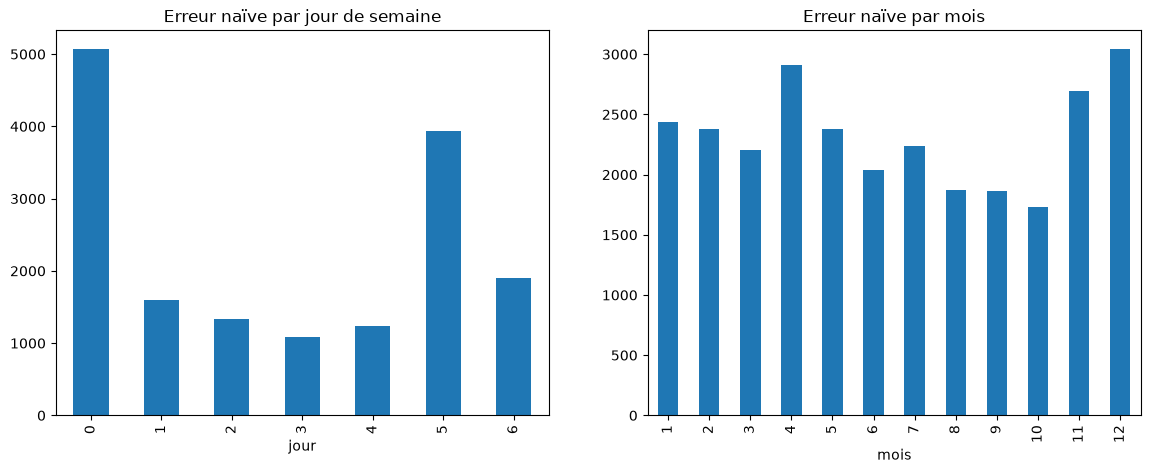

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df_2024.groupby('jour')['erreur_jour'].mean().plot(kind='bar', ax=ax1, title='Erreur naïve par jour de semaine')
df_2024.groupby('mois')['erreur_jour'].mean().plot(kind='bar', ax=ax2, title='Erreur naïve par mois')

On voit clairement là où on se trompe le plus. Sur les jours de la semaine, on se trompe surtout pour le lundi et le samedi, 5000 MW et 4000 MW d'erreur respectivement, soit presque le double de notre erreur moyenne (2316 MW), on peut expliquer cela par le fait que ce soient les deux jours frontaliers entre jours de semaine et weekend, les deux tranches de la semaine qui varient le plus entre elles, et vu que la méthode naïve copie la veille, c'est exactement sur ces transitions qu'elle se plante.

Pour les mois, on se trompe surtout pour les mois d'avril, novembre et décembre, avec des erreurs autour des 3000 MW par jour pour ces 3 extremums, soit environ 30% de plus que la moyenne annuelle. En effet, ce sont des mois à météo instable où deux jours qui se suivent peuvent être très différents, et ce sont aussi des mois avec plusieurs jours fériés (Pâques, le 1er et le 11 novembre, Noël), des ruptures que la méthode naïve ne peut pas prévoir.

In [16]:
df_jour['weekend']=(df_jour['date'].dt.dayofweek >=5).astype(int)

In [17]:
df_jour=df_jour.dropna(subset=['conso_veille'])

In [18]:
len(df_jour)

730

In [19]:
train=df_jour[df_jour['date'].dt.year==2023]

In [20]:
test=df_jour[df_jour['date'].dt.year==2024]

In [21]:
test.describe()

,consommation,temp_france,conso_veille,weekend
count,366.000000,366.000000,366.000000,366.000000
mean,50101.382012,13.220200,50062.692861,0.284153
std,8922.601922,5.773673,8884.035318,0.451627
min,36375.791667,-1.277083,36375.791667,0.000000
25%,44146.953125,8.553906,44146.953125,0.000000
50%,46858.572917,13.103906,46858.572917,0.000000
75%,57073.796875,17.432812,56905.760417,1.000000
max,78160.708333,26.180208,78160.708333,1.000000


In [22]:
len(train)

364

In [23]:
len(test)

366

## Modèle linéaire : veille, température, weekend

In [24]:
from sklearn.linear_model import LinearRegression   

colonnes = ["conso_veille", "temp_france", "weekend"]  

X_train = train[colonnes]        
y_train = train["consommation"]  

modele = LinearRegression()      
modele.fit(X_train, y_train)     

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.71, -369.83,-4427.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['conso_veille','temp_france','weekend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [25]:
modele.coef_

array([ 7.07270810e-01, -3.69830183e+02, -4.42736187e+03])

In [26]:
predictions = modele.predict(test[colonnes])

In [27]:
mae_modele = (test["consommation"]    - predictions).abs().mean()

In [28]:
mae_modele

np.float64(1675.0085111199305)

On constate que notre modèle bat clairement la méthode naïve, avec une erreur moyenne de 1675 MW contre 2316 MW, soit une amélioration de 28%. Autrement dit, en donnant au modèle la conso de la veille, la température et le type de jour, on se trompe d'environ 3% de la consommation moyenne journalière, ce qui est déjà très correct pour un modèle linéaire à 3 paramètres.

Les coefficients du modèle confirment nos analyses précédentes, en effet, le coefficient du weekend vaut -4427 MW, ce qui correspond bien à l'écart semaine/weekend qu'on avait mesuré dans l'exploration (environ 5000 MW). Pour la température, le coefficient vaut seulement -370 MW/°C alors qu'on avait mesuré une thermosensibilité de -2066 MW/°C, on peut expliquer cela par la colinéarité entre nos variables : la conso de la veille contient déjà l'effet de la température de la veille, et comme la température change peu d'un jour à l'autre, le modèle n'attribue à la température que ce qu'elle apporte en plus, c'est-à-dire l'effet des variations de température entre deux jours. 

Pour être honnête, j'avais parié sur une erreur autour de 770 MW (l'erreur divisée par 3 vu qu'on a 3 paramètres), pari largement perdu, le nombre de paramètres ne divise pas l'erreur, chaque variable n'apporte que l'information nouvelle qu'elle contient. Le modèle reste aussi limité par ce qu'il ne connaît pas, notamment les jours fériés qu'il traite comme des jours normaux.

In [29]:
test['prediction']=predictions

In [30]:
test['erreur_modele']=(test['consommation']-test['prediction']).abs()

In [31]:
test['jour']=test['date'].dt.dayofweek

In [32]:
test['mois']=test['date'].dt.month

<Axes: title={'center': 'Erreur modele par mois'}, xlabel='mois'>

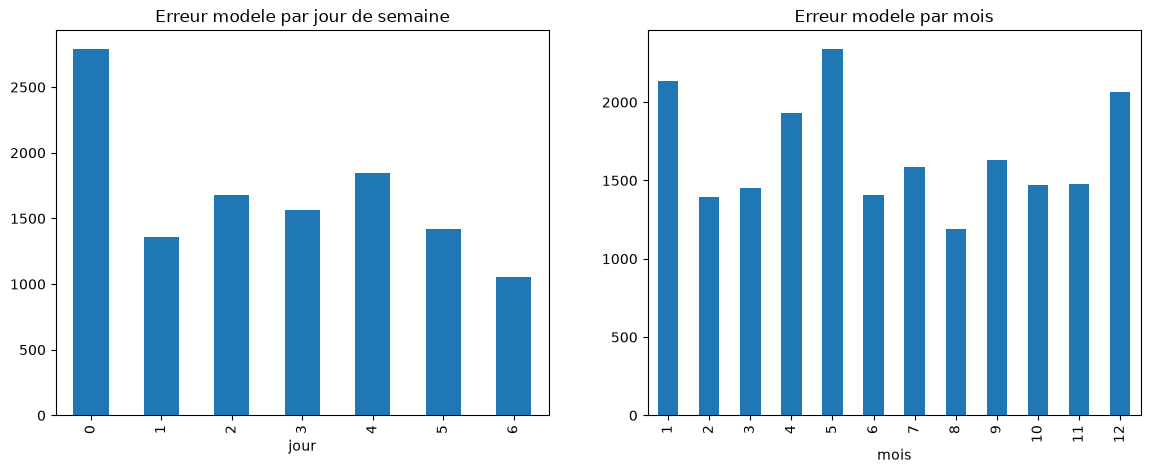

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
test.groupby('jour')['erreur_modele'].mean().plot(kind='bar', ax=ax1, title='Erreur modele par jour de semaine')
test.groupby('mois')['erreur_modele'].mean().plot(kind='bar', ax=ax2, title='Erreur modele par mois')

Pour les jours de la semaine, le lundi garde la plus grosse erreur (environ 2800 MW) comme pour la naïve, mais en nettement mieux quand même (on était à 5000 MW). Surtout, on n'a plus le pic du samedi (environ 4000 MW pour la naïve contre 1500 MW maintenant), d'où l'intérêt de la feature weekend. On suppose alors que l'erreur du lundi vient du fait que sa feature conso_veille a été impactée par le dimanche, le jour le moins consommateur de la semaine : le meilleur indice du modèle est piégé ce jour-là, et une feature "la veille était un weekend" pourrait corriger ça.

Pour les mois, le mois de mai passe en tête (environ 2400 MW), on peut expliquer ça par les jours fériés de mai (le 1er, le 8, l'Ascension, souvent la Pentecôte) que le modèle traite comme des jours normaux, c'est d'ailleurs la démonstration la plus claire de sa limite : un mois sans météo extrême devient le plus imprévisible juste à cause du calendrier. Janvier, avril et décembre restent en tête pour les mêmes raisons que la naïve (environ 2200, 1900 et 2100 MW respectivement), entre coups de froid et jours fériés. La prochaine amélioration évidente serait donc d'ajouter les jours fériés et la nature de la veille comme features du modèle.

## Amélioration : jours fériés et veille de repos

Suite à l'analyse d'erreur, on ajoute deux features au modèle : les jours fériés (que le modèle traitait comme des jours normaux, d'où le pic du mois de mai) et la veille de repos (pour corriger le lundi, dont la conso_veille est piégée par le dimanche). Mon pari avant de relancer : une MAE autour de 1400 MW contre 1675 actuellement. Le raisonnement : les 52 lundis et la vingtaine de jours fériés représentent environ 20% des jours mais une part bien plus grosse de l'erreur totale vu leurs erreurs au-dessus de la moyenne, si les nouvelles features corrigent une bonne partie de cet excès, l'erreur moyenne devrait baisser de quelques centaines de MW.

In [34]:
FERIES = pd.to_datetime([
    "2023-01-01", "2023-04-10", "2023-05-01", "2023-05-08", "2023-05-18",
    "2023-05-29", "2023-07-14", "2023-08-15", "2023-11-01", "2023-11-11", "2023-12-25",
    "2024-01-01", "2024-04-01", "2024-05-01", "2024-05-08", "2024-05-09",
    "2024-05-20", "2024-07-14", "2024-08-15", "2024-11-01", "2024-11-11", "2024-12-25",
]).tz_localize("UTC")

In [35]:
df_jour['ferie']=df_jour['date'].isin(FERIES).astype(int)

In [36]:
df_jour['veille_repos']=(df_jour['ferie'] + df_jour['weekend'] >= 1).astype(int)

In [37]:
df_jour["veille_repos"] = df_jour["veille_repos"].shift(1).fillna(0).astype(int)

In [38]:
df_jour.describe()

,consommation,temp_france,conso_veille,weekend,ferie,veille_repos
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,49922.117754,13.515476,49890.607451,0.284932,0.028767,0.310959
std,9121.425564,6.182986,9105.480285,0.451691,0.167266,0.463203
min,35818.604167,-1.277083,35818.604167,0.000000,0.000000,0.000000
25%,43776.875000,8.801953,43766.036458,0.000000,0.000000,0.000000
50%,46669.177083,13.160156,46650.812500,0.000000,0.000000,0.000000
75%,56713.401042,18.792318,56640.520833,1.000000,0.000000,1.000000
max,78160.708333,27.153125,78160.708333,1.000000,1.000000,1.000000


In [39]:
train=df_jour[df_jour['date'].dt.year==2023]
test=df_jour[df_jour['date'].dt.year==2024]

In [40]:
colonnes_v2 = ["conso_veille", "temp_france", "weekend", "ferie", "veille_repos"]

In [41]:
X_train = train[colonnes_v2]        
y_train = train["consommation"]  

modele_v2 = LinearRegression()      
modele_v2.fit(X_train, y_train)     

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.86, -189.41,-5401.2 ,-4481.27, 3780.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['conso_veille','temp_france','weekend','ferie','veille_repos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.013e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [42]:
modele_v2.coef_

array([ 8.59448770e-01, -1.89411705e+02, -5.40120336e+03, -4.48127294e+03,
        3.78041916e+03])

In [43]:
predictions_v2 = modele_v2.predict(test[colonnes_v2])

In [44]:
mae_modele_v2 = (test["consommation"]    - predictions_v2).abs().mean()

In [45]:
mae_modele_v2

np.float64(1126.3013520082777)

On constate que le modèle v2 améliore encore nettement les résultats : la MAE passe de 2316 MW (naïve) à 1675 MW (modèle v1) puis à 1126 MW, soit une réduction de 51% par rapport à la naïve. Autrement dit, on se trompe en moyenne d'environ 2% de la consommation journalière, avec une simple régression linéaire à 5 features construites à partir de nos propres analyses d'erreur.

Les coefficients confirment nos hypothèses, en effet, le modèle attribue -4481 MW aux jours fériés, autrement dit un jour férié "coûte" presque autant qu'un jour de weekend (-5401 MW), ce qui est logique vu que l'activité économique s'arrête pareil, c'était exactement ce qui manquait au modèle v1 et ce qui expliquait le pic d'erreur du mois de mai. Le coefficient de veille_repos vaut +3780 MW, le signe positif peut surprendre mais il est logique : quand la veille était un jour de repos, la conso_veille est anormalement basse, et le modèle doit donc corriger sa prédiction vers le haut, c'est exactement le remède au problème du lundi qu'on avait diagnostiqué. Enfin le coefficient de la température continue de baisser (-189 MW/°C), la colinéarité s'accentue vu que nos nouvelles features absorbent une partie de l'information.

Pour l'anecdote, mon premier instinct pariait sur 1200 MW, puis je me suis laissé influencer vers 1400 en voyant une estimation externe à 1450, et le résultat final (1126) a donné raison à mon instinct initial. Leçon retenue sur le biais d'ancrage : une intuition construite sur ses propres analyses mérite parfois qu'on la défende.

In [46]:
test['prediction']=predictions_v2
test['erreur_modele']=(test['consommation']-test['prediction']).abs()
test['jour']=test['date'].dt.dayofweek
test['mois']=test['date'].dt.month

<Axes: title={'center': 'Erreur modele par mois'}, xlabel='mois'>

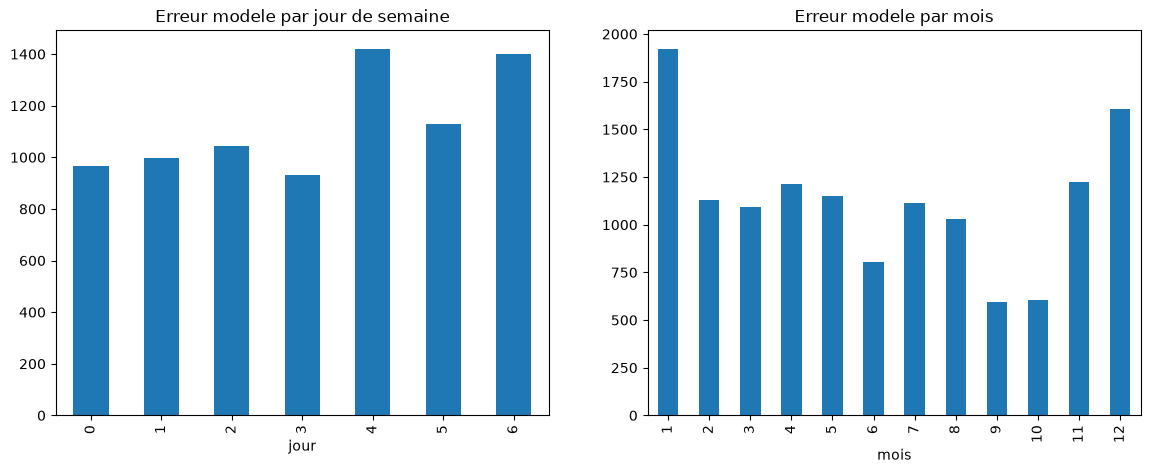

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
test.groupby('jour')['erreur_modele'].mean().plot(kind='bar', ax=ax1, title='Erreur modele par jour de semaine')
test.groupby('mois')['erreur_modele'].mean().plot(kind='bar', ax=ax2, title='Erreur modele par mois')

On constate que les deux corrections ont fait exactement ce qu'on attendait d'elles. Le lundi est guéri : son erreur passe d'environ 2800 MW à 950 MW, il passe même de pire jour de la semaine à l'un des meilleurs, la feature veille_repos a bien corrigé le piège du dimanche sur conso_veille. Le mois de mai est détrôné lui aussi, son erreur passe d'environ 2400 MW à 1150 MW, les jours fériés sont maintenant bien anticipés par le modèle.

On remarque alors que le nouveau champion de l'erreur, c'est l'hiver : janvier (environ 1900 MW) et décembre (environ 1600 MW) dominent largement. C'est logique, une fois le calendrier soigné, il reste la météo : notre coefficient de température, affaibli par la colinéarité avec conso_veille, capture mal les coups de froid brutaux, et c'est là que vit désormais l'essentiel de l'erreur résiduelle.

Côté jours de la semaine, les nouveaux pires jours sont le vendredi et le dimanche (environ 1400 MW chacun). Pour le vendredi, on peut expliquer cela par les ponts : l'Ascension tombe toujours un jeudi, et le vendredi qui suit est chômé dans beaucoup d'entreprises sans être un jour férié officiel, donc absent de notre liste. Pour le dimanche, notre unique feature weekend moyenne le samedi et le dimanche alors qu'ils diffèrent d'environ 1700 MW de consommation, un seul coefficient pour deux réalités se trompe un peu sur les deux.

Pistes d'amélioration futures : une feature "degrés de chauffe" (max(0, 15 − T)) pour mieux coller à la relation non linéaire température-consommationet des drapeaux séparés pour samedi et dimanche.